# Proyecto 1 - Fase 1 (Predicción de GRD)

Este notebook implementa una solución completa y reproducible para la Fase 1:

1. Carga y revisión de todas las fuentes (`CSV` y tablas `XLSX`).
2. Análisis exploratorio y calidad de datos (completitud, correctitud, outliers).
3. Ingeniería de características para diagnósticos/procedimientos (multi-etiqueta).
4. Entrenamiento y comparación de modelos de clasificación multiclase para predecir `GRD`.
5. Selección del mejor modelo, análisis de desempeño y exportación del artefacto entrenado.

> Nota metodológica: este problema es de **alta cardinalidad multiclase** (muchos GRD), por lo que se privilegian modelos lineales y probabilísticos eficientes en representaciones dispersas (`sparse`).

In [20]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
project_dir = Path.cwd()

print("Directorio de trabajo:", project_dir)

Directorio de trabajo: c:\Users\renat\Downloads\Proyecto Fase 1


## 1) Carga de datos y revisión de archivos

En esta sección:
- Cargamos el dataset principal.
- Identificamos columnas clave (`Diag`, `Proced`, `Edad`, `Sexo`, `GRD`).
- Revisamos que los archivos auxiliares estén disponibles para documentación y análisis de contexto.

In [21]:
def read_csv_with_fallback(path: Path) -> tuple[pd.DataFrame, str]:
    """Carga CSV probando codificaciones comunes en datasets sanitarios de Chile."""
    for enc in ("utf-8-sig", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, sep=";", encoding=enc), enc
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("No fue posible leer el CSV con las codificaciones probadas.")


def summarize_excel(path: Path) -> pd.DataFrame:
    """Resume hojas y dimensiones de un archivo Excel."""
    xl = pd.ExcelFile(path)
    rows = []
    for sheet in xl.sheet_names:
        shape = pd.read_excel(path, sheet_name=sheet).shape
        rows.append({"archivo": path.name, "sheet": sheet, "filas": shape[0], "columnas": shape[1]})
    return pd.DataFrame(rows)


main_csv = project_dir / "dataset_elpino.csv"
aux_files = [
    project_dir / "CIE-9.xlsx",
    project_dir / "CIE-10.xlsx",
    project_dir / "IR-GRD V3.1 CON PRECIOS FONASA 2016.xlsx",
    project_dir / "Tablas maestras bases GRD.xlsx",
]

df, csv_encoding = read_csv_with_fallback(main_csv)
print(f"CSV cargado con encoding: {csv_encoding}")
print(f"Dimensión dataset principal: {df.shape}")

# Detección robusta de columnas principales
age_col = next(c for c in df.columns if "Edad" in c)
sex_col = next(c for c in df.columns if "Sexo" in c)
target_col = "GRD"
diag_cols = [c for c in df.columns if c.startswith("Diag")]
proc_cols = [c for c in df.columns if c.startswith("Proced")]

print(f"Columnas diagnóstico: {len(diag_cols)}")
print(f"Columnas procedimiento: {len(proc_cols)}")
print(f"Columna edad: {age_col}")
print(f"Columna sexo: {sex_col}")
print(f"Variable objetivo: {target_col}")

print("\nPrimeras filas del dataset principal:")
display(df.head(3))

summary_list = []
for f in aux_files:
    if f.exists():
        summary_list.append(summarize_excel(f))
    else:
        print(f"No encontrado: {f.name}")

if summary_list:
    aux_summary = pd.concat(summary_list, ignore_index=True)
    print("\nResumen de archivos auxiliares (XLSX):")
    display(aux_summary)

CSV cargado con encoding: utf-8-sig
Dimensión dataset principal: (14561, 68)
Columnas diagnóstico: 35
Columnas procedimiento: 30
Columna edad: Edad en años
Columna sexo: Sexo (Desc)
Variable objetivo: GRD

Primeras filas del dataset principal:


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga,...",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,F19.2 - Trastornos mentales y del comportamien...,F10.2 - Trastornos mentales y del comportamien...,"E46 - Desnutrición proteicocalórica, no especi...","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,99.19 - INYECCION ANTICOAGULANTE,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,93.94 - AEROSOLTERAPIA,89.52 - ELECTROCARDIOGRAFIA,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.65 - GASOMETRIA ARTERIA,39.95 - HEMODIALISIS,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,88.7


Resumen de archivos auxiliares (XLSX):


,archivo,sheet,filas,columnas
0,CIE-9.xlsx,CIE 9,4646,5
1,CIE-10.xlsx,CIE 10,39873,6
2,IR-GRD V3.1 CON PRECIOS FONASA 2016.xlsx,IR-GRD v3.1,1095,8
3,Tablas maestras bases GRD.xlsx,Hospitales,377,2
4,Tablas maestras bases GRD.xlsx,Tipo de Pabellon,8,2
5,Tablas maestras bases GRD.xlsx,IR - GRD,1066,2
6,Tablas maestras bases GRD.xlsx,Severidad GRD,4,2
7,Tablas maestras bases GRD.xlsx,Mortalidad GRD,4,2


## 2) Calidad de datos: completitud, correctitud y outliers

Criterios evaluados:
- **Completitud**: proporción de valores faltantes (`NaN` o `-`).
- **Correctitud**: validación básica de formato en códigos diagnósticos/procedimientos.
- **Outliers**: detección de edades fuera de rango clínicamente plausible.

Top 10 columnas con mayor tasa de faltantes:


,% faltantes
Diag 35 Secundario (cod+des),99.81
Diag 34 Secundario (cod+des),99.73
Diag 33 Secundario (cod+des),99.70
Diag 32 Secundario (cod+des),99.61
Diag 31 Secundario (cod+des),99.54
Diag 30 Secundario (cod+des),99.48
Diag 29 Secundario (cod+des),99.36
Diag 28 Secundario (cod+des),99.24
Diag 27 Secundario (cod+des),99.11
Diag 26 Secundario (cod+des),98.94



Registros duplicados exactos: 144
Edad promedio: 39.43
Edad mínima: 0 | Edad máxima: 121
Posibles outliers de edad (<0 o >110): 1

Códigos diagnóstico válidos (regex): 100.00%
Códigos procedimiento válidos (regex): 100.00%


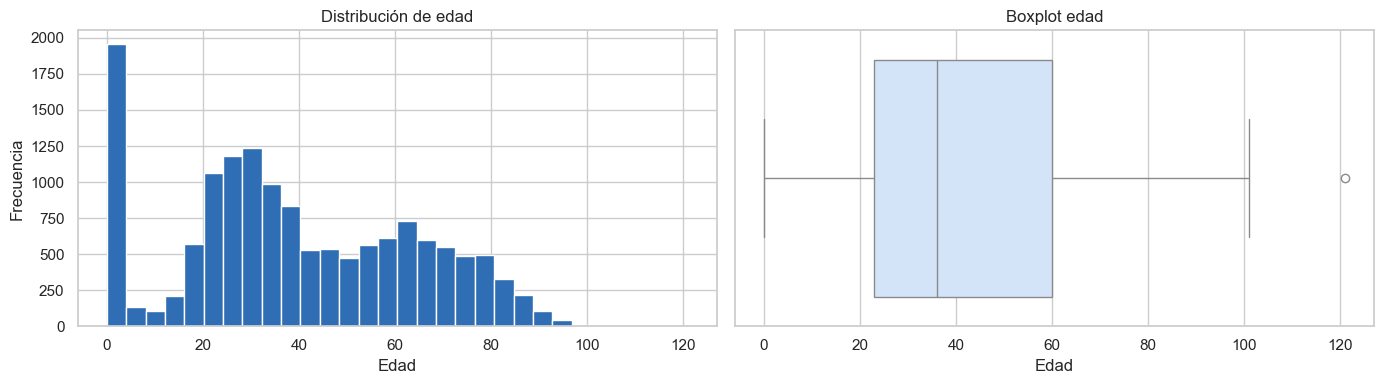

In [22]:
def extract_code(value):
    """Extrae el código previo al separador ' - ' y limpia marcadores vacíos."""
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text in {"", "-", "nan", "None"}:
        return None
    return text.split(" - ")[0].strip()


# Completitud
missing_like = df.replace("-", np.nan)
missing_ratio = missing_like.isna().mean().sort_values(ascending=False)

print("Top 10 columnas con mayor tasa de faltantes:")
display((missing_ratio.head(10) * 100).round(2).to_frame("% faltantes"))

print("\nRegistros duplicados exactos:", int(df.duplicated().sum()))

# Outliers edad
age_numeric = pd.to_numeric(df[age_col], errors="coerce")
outliers_age = ((age_numeric < 0) | (age_numeric > 110)).sum()
print(f"Edad promedio: {age_numeric.mean():.2f}")
print(f"Edad mínima: {age_numeric.min()} | Edad máxima: {age_numeric.max()}")
print(f"Posibles outliers de edad (<0 o >110): {int(outliers_age)}")

# Correctitud formato básico de códigos
all_diag_codes = pd.Series([extract_code(v) for v in df[diag_cols].to_numpy().ravel()]).dropna()
all_proc_codes = pd.Series([extract_code(v) for v in df[proc_cols].to_numpy().ravel()]).dropna()

diag_pattern = r"^[A-Z][0-9]{2}(\.[A-Z0-9]+)?$"
proc_pattern = r"^[0-9]{2}(\.[0-9]{1,2})?$"

diag_valid_ratio = all_diag_codes.str.match(diag_pattern, na=False).mean()
proc_valid_ratio = all_proc_codes.str.match(proc_pattern, na=False).mean()

print(f"\nCódigos diagnóstico válidos (regex): {diag_valid_ratio * 100:.2f}%")
print(f"Códigos procedimiento válidos (regex): {proc_valid_ratio * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(age_numeric.dropna(), bins=30, color="#2f6db5", edgecolor="white")
axes[0].set_title("Distribución de edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(x=age_numeric, ax=axes[1], color="#cde3ff")
axes[1].set_title("Boxplot edad")
axes[1].set_xlabel("Edad")

plt.tight_layout()
plt.show()

## 3) Análisis exploratorio enfocado al problema

Visualizamos distribución de clases y variables más frecuentes para entender desbalance y complejidad del dataset.

Cantidad de clases GRD: 526
Muestras totales: 14561


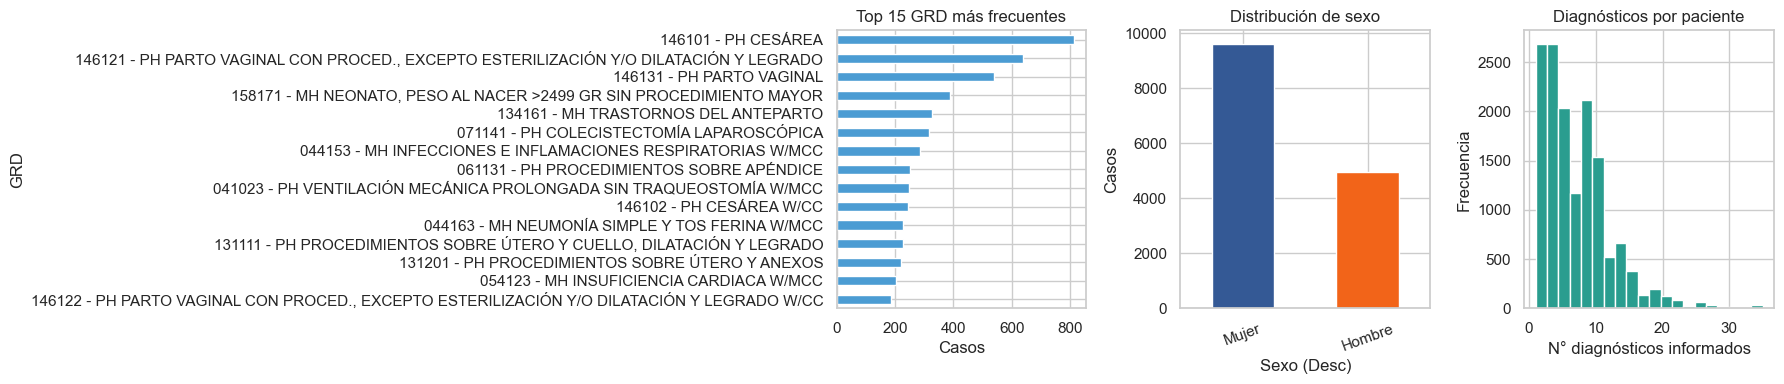

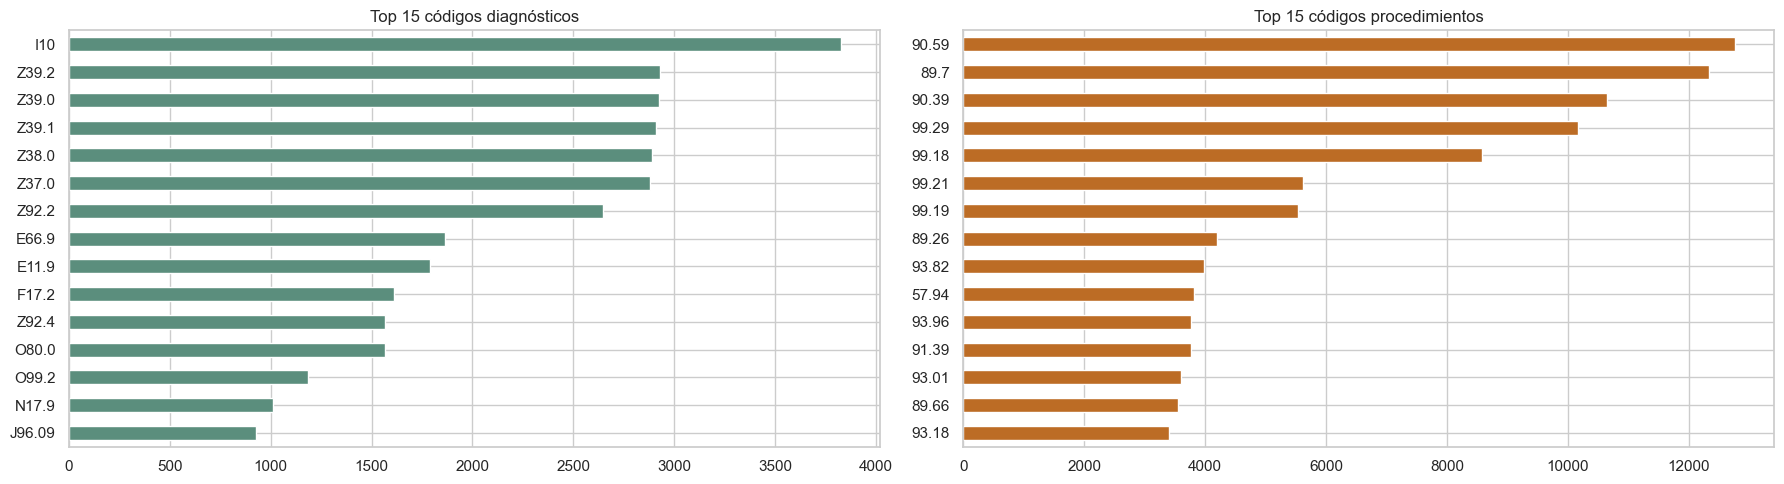

In [23]:
grd_counts = df[target_col].astype(str).value_counts()
print(f"Cantidad de clases GRD: {grd_counts.shape[0]}")
print(f"Muestras totales: {len(df)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Top clases GRD
(grd_counts.head(15).sort_values()).plot(kind="barh", ax=axes[0], color="#4b9cd3")
axes[0].set_title("Top 15 GRD más frecuentes")
axes[0].set_xlabel("Casos")

# Sexo
sex_counts = df[sex_col].astype(str).value_counts()
sex_counts.plot(kind="bar", ax=axes[1], color=["#345995", "#f26419", "#6c757d"])
axes[1].set_title("Distribución de sexo")
axes[1].set_ylabel("Casos")
axes[1].tick_params(axis="x", rotation=20)

# Cantidad de diagnósticos por paciente
diag_per_patient = df[diag_cols].apply(lambda row: sum(extract_code(v) is not None for v in row), axis=1)
axes[2].hist(diag_per_patient, bins=20, color="#2a9d8f", edgecolor="white")
axes[2].set_title("Diagnósticos por paciente")
axes[2].set_xlabel("N° diagnósticos informados")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Top códigos diagnóstico/procedimiento
top_diag = all_diag_codes.value_counts().head(15)
top_proc = all_proc_codes.value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
(top_diag.sort_values()).plot(kind="barh", ax=axes[0], color="#5b8e7d")
axes[0].set_title("Top 15 códigos diagnósticos")

(top_proc.sort_values()).plot(kind="barh", ax=axes[1], color="#bc6c25")
axes[1].set_title("Top 15 códigos procedimientos")

plt.tight_layout()
plt.show()

## 4) Preparación de características y partición de datos

Se construye una representación `sparse`:
- Diagnósticos y procedimientos como multi-etiqueta binaria.
- Sexo como one-hot.
- Edad como variable numérica.

Además, se filtran clases con menos de 2 ejemplos para permitir `stratified split` estable.

In [24]:
model_df = df[diag_cols + proc_cols + [age_col, sex_col, target_col]].copy()
model_df[target_col] = model_df[target_col].astype(str).str.strip()

# Filtrar clases extremadamente raras para split estratificado robusto
grd_count = model_df[target_col].value_counts()
keep_mask = model_df[target_col].map(grd_count) >= 2
removed_rows = (~keep_mask).sum()
model_df = model_df.loc[keep_mask].reset_index(drop=True)

print(f"Filas removidas por clases con <2 muestras: {removed_rows}")
print(f"Dataset para modelado: {model_df.shape}")
print(f"Clases GRD en modelado: {model_df[target_col].nunique()}")

# Construcción de listas de códigos por paciente
diag_lists = model_df[diag_cols].apply(lambda row: [c for c in (extract_code(v) for v in row) if c], axis=1)
proc_lists = model_df[proc_cols].apply(lambda row: [c for c in (extract_code(v) for v in row) if c], axis=1)

# Encode multi-etiqueta
mlb_diag = MultiLabelBinarizer(sparse_output=True)
mlb_proc = MultiLabelBinarizer(sparse_output=True)
X_diag = mlb_diag.fit_transform(diag_lists)
X_proc = mlb_proc.fit_transform(proc_lists)

# Encode sexo
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_sex = ohe.fit_transform(model_df[[sex_col]].fillna("Desconocido").astype(str))

# Edad numérica limpia
age_model = pd.to_numeric(model_df[age_col], errors="coerce")
age_model = age_model.fillna(age_model.median()).clip(lower=0, upper=110)
X_age = csr_matrix(age_model.to_numpy().reshape(-1, 1))

# Matriz final
X = hstack([X_diag, X_proc, X_sex, X_age], format="csr")
y = model_df[target_col]

print(f"Forma matriz X: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Filas removidas por clases con <2 muestras: 76
Dataset para modelado: (14485, 68)
Clases GRD en modelado: 450
Forma matriz X: (14485, 4514)
Train: (11588, 4514), Test: (2897, 4514)


## 5) Entrenamiento y comparación de modelos

Métricas usadas para selección:
- `accuracy`
- `F1-macro` (crítica por desbalance y muchas clases)
- `F1-weighted`

In [25]:
models = {
    "Dummy-most-frequent": DummyClassifier(strategy="most_frequent"),
    "ComplementNB": ComplementNB(alpha=0.5),
    "SGD-log-loss": SGDClassifier(
        loss="log_loss",
        alpha=1e-5,
        penalty="l2",
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LinearSVC": LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
}

results = []
fitted_models = {}
preds_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
    }

    results.append(metrics)
    fitted_models[name] = model
    preds_by_model[name] = pred

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(results_df.style.format({"accuracy": "{:.4f}", "f1_macro": "{:.4f}", "f1_weighted": "{:.4f}"}))

best_name = results_df.loc[0, "model"]
best_model = fitted_models[best_name]
best_pred = preds_by_model[best_name]

print(f"Mejor modelo por F1-macro: {best_name}")

,model,accuracy,f1_macro,f1_weighted
0,LinearSVC,0.6514,0.3314,0.6376
1,ComplementNB,0.4556,0.1510,0.3587
2,SGD-log-loss,0.2658,0.0915,0.2393
3,Dummy-most-frequent,0.0563,0.0003,0.0060


Mejor modelo por F1-macro: LinearSVC


## 6) Evaluación detallada del mejor modelo

Reporte de clasificación en las 20 clases más frecuentes (test):
                                                                                             precision    recall  f1-score   support

                                                                        146101 - PH CESÁREA       0.92      0.94      0.93       163
     146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO       0.93      1.00      0.96       128
                                                                  146131 - PH PARTO VAGINAL       0.93      0.93      0.93       108
                        158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR       0.83      0.76      0.79        78
                                                       134161 - MH TRASTORNOS DEL ANTEPARTO       0.86      0.78      0.82        65
                                                  071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.85      0.92      0.89        63
   

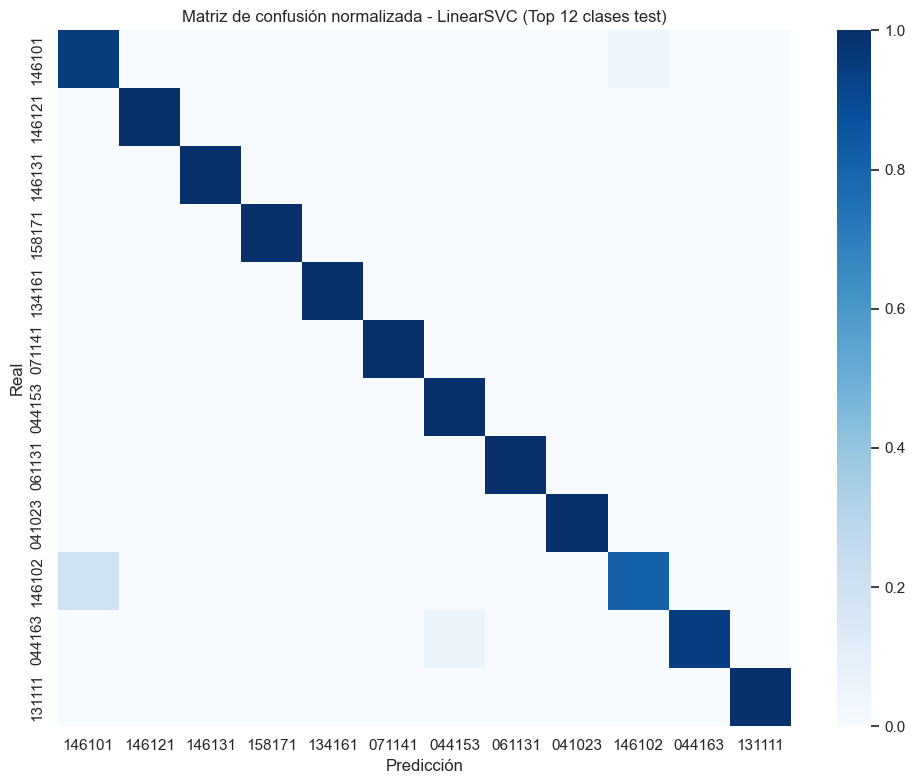

Métricas globales del mejor modelo:
- accuracy: 0.6514
- f1_macro: 0.3314
- f1_weighted: 0.6376


In [26]:
# Reporte para clases con mayor soporte en test (más interpretable que 500+ clases)
major_classes = y_test.value_counts().head(20).index
print("Reporte de clasificación en las 20 clases más frecuentes (test):")
print(classification_report(y_test, best_pred, labels=major_classes, zero_division=0))

# Matriz de confusión normalizada para top 12 clases
cm_labels = y_test.value_counts().head(12).index
cm = confusion_matrix(y_test, best_pred, labels=cm_labels, normalize="true")
short_labels = [lbl.split(" - ")[0] if " - " in lbl else lbl for lbl in cm_labels]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", xticklabels=short_labels, yticklabels=short_labels)
plt.title(f"Matriz de confusión normalizada - {best_name} (Top 12 clases test)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# Distribución de desempeño global
global_metrics = {
    "accuracy": accuracy_score(y_test, best_pred),
    "f1_macro": f1_score(y_test, best_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, best_pred, average="weighted", zero_division=0),
}

print("Métricas globales del mejor modelo:")
for k, v in global_metrics.items():
    print(f"- {k}: {v:.4f}")

## 7) Importancia de variables y guardado del modelo

Se calcula importancia global solo para modelos lineales (`coef_`) y se exporta el artefacto para reproducibilidad.

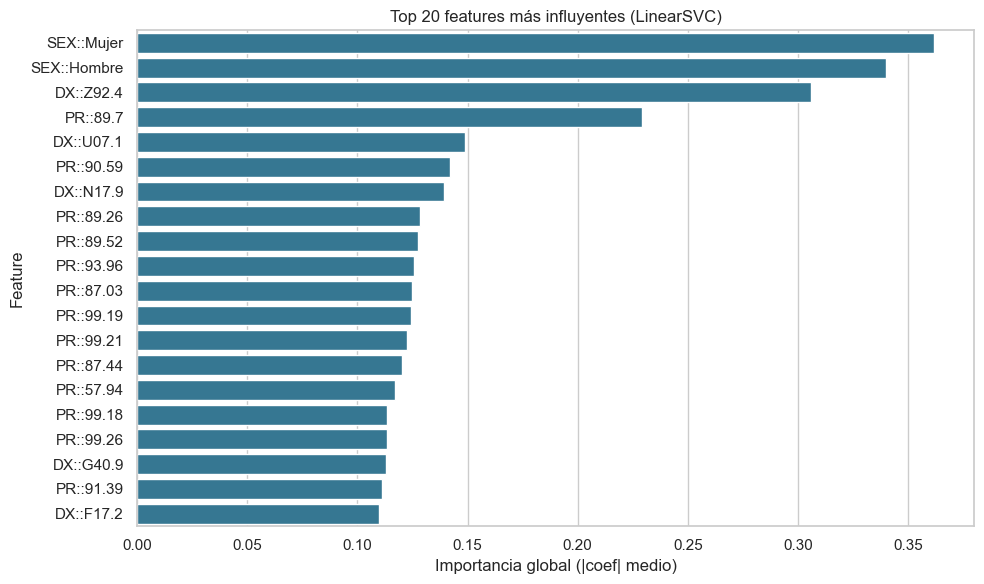

,feature,importance
0,SEX::Mujer,0.361862
1,SEX::Hombre,0.340157
2,DX::Z92.4,0.305819
3,PR::89.7,0.229081
4,DX::U07.1,0.148823
5,PR::90.59,0.141865
6,DX::N17.9,0.139552
7,PR::89.26,0.128272
8,PR::89.52,0.127613
9,PR::93.96,0.125864


Artefacto guardado en: c:\Users\renat\Downloads\Proyecto Fase 1\artifacts\fase1_best_model.joblib


In [27]:
import joblib

feature_names = (
    [f"DX::{c}" for c in mlb_diag.classes_]
    + [f"PR::{c}" for c in mlb_proc.classes_]
    + [f"SEX::{c}" for c in ohe.categories_[0]]
    + ["AGE"]
)

if hasattr(best_model, "coef_"):
    # Importancia global aproximada: media del valor absoluto de coeficientes por feature
    coef_abs = np.abs(best_model.coef_)
    global_importance = np.asarray(coef_abs.mean(axis=0)).ravel()
    top_idx = np.argsort(global_importance)[-20:][::-1]

    top_features = pd.DataFrame(
        {
            "feature": [feature_names[i] for i in top_idx],
            "importance": global_importance[top_idx],
        }
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_features, x="importance", y="feature", color="#277da1")
    plt.title(f"Top 20 features más influyentes ({best_name})")
    plt.xlabel("Importancia global (|coef| medio)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(top_features)
else:
    print(f"{best_name} no expone coeficientes lineales para interpretar importancia global.")

artifacts_dir = project_dir / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

artifact_path = artifacts_dir / "fase1_best_model.joblib"
joblib.dump(
    {
        "model_name": best_name,
        "model": best_model,
        "mlb_diag": mlb_diag,
        "mlb_proc": mlb_proc,
        "ohe_sex": ohe,
        "diag_cols": diag_cols,
        "proc_cols": proc_cols,
        "age_col": age_col,
        "sex_col": sex_col,
        "target_col": target_col,
        "metrics": global_metrics,
    },
    artifact_path,
)

print(f"Artefacto guardado en: {artifact_path}")

## 8) Conclusiones automáticas (base para tu informe)

- El problema presenta **alta cardinalidad de salida** (muchas clases GRD), con desbalance importante.
- La ingeniería de variables basada en códigos clínicos (`Diag`, `Proced`) permite representar adecuadamente la información médica.
- Se compararon varios modelos y se seleccionó el mejor según `F1-macro` para balancear desempeño entre clases frecuentes y poco frecuentes.
- Se generó un artefacto serializado para reproducibilidad, facilitando su integración en el repositorio del curso.

### Recomendaciones para mejorar en Fase 1
1. Realizar tuning de hiperparámetros del modelo ganador con `RandomizedSearchCV`.
2. Probar reducción de dimensionalidad para códigos extremadamente raros.
3. Evaluar métricas top-k (por ejemplo `top-3 accuracy`) para escenarios clínicos con múltiples GRD plausibles.